Here are some short examples related to the presentation on covolutional neural networks.

In [1]:
# Import required packages
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps
from Functions import *

## Standard neural network

Let's start by fitting a standard neural network. We will use a dataset of images with the goal of classifying the images into categories of what they depict. This is a standard dataset used for understanding image analysis and convolutional neural networks. In this case, though, we'll assume that the spatial component of the images is unimportant and just use a standard neural network.

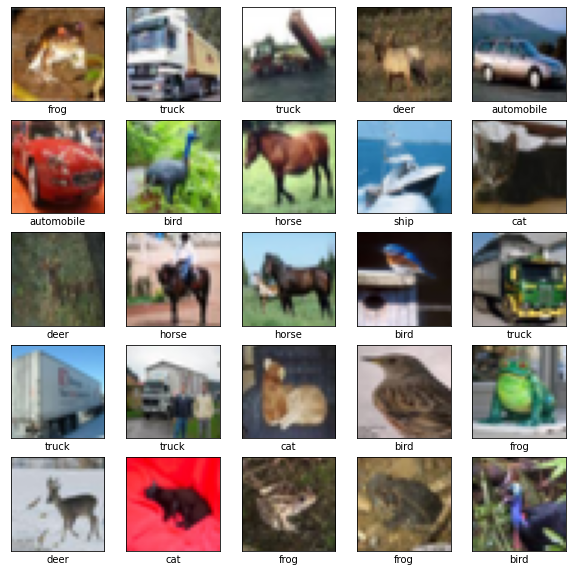

In [2]:
# Load CIFAR dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
              'dog', 'frog', 'horse', 'ship', 'truck']

# Plot sample data
plt.figure(figsize = (10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [3]:
# Create the model
model = models.Sequential()
model.add(layers.Flatten())
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dense(10))

In [4]:
# Compile & fit the model
model.compile(optimizer = 'adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
             metrics = ['accuracy'])

history = model.fit(train_images, train_labels, epochs = 10,
                   validation_data = (test_images, test_labels))

Epoch 1/10
1563/1563 [==============================] - 3s 2ms/step - loss: 2.0783 - accuracy: 0.1876 - val_loss: 2.0102 - val_accuracy: 0.2211
Epoch 2/10
1563/1563 [==============================] - 2s 1ms/step - loss: 1.9432 - accuracy: 0.2812 - val_loss: 1.9074 - val_accuracy: 0.2954
Epoch 3/10
1563/1563 [==============================] - 2s 1ms/step - loss: 1.9064 - accuracy: 0.2992 - val_loss: 1.9215 - val_accuracy: 0.2913
Epoch 4/10
1563/1563 [==============================] - 2s 1ms/step - loss: 1.8841 - accuracy: 0.3053 - val_loss: 1.8793 - val_accuracy: 0.3098
Epoch 5/10
1563/1563 [==============================] - 2s 1ms/step - loss: 1.8693 - accuracy: 0.3132 - val_loss: 1.8849 - val_accuracy: 0.3000
Epoch 6/10
1563/1563 [==============================] - 2s 1ms/step - loss: 1.8614 - accuracy: 0.3162 - val_loss: 1.8551 - val_accuracy: 0.3173
Epoch 7/10
1563/1563 [==============================] - 2s 2ms/step - loss: 1.8525 - accuracy: 0.3214 - val_loss: 1.8496 - val_accuracy:

In [5]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose = 2)
print(test_acc)

313/313 - 0s - loss: 1.8388 - accuracy: 0.3203 - 248ms/epoch - 794us/step
0.32030001282691956


## Convolution

Let's take a look at how convolution works in Python before jumping into convolutional neural networks. In this short exercise, you'll perform convolution on an image of your choice. In this case, you'll filter the image for edges. This is a common practice in image identification because more information is helded in image "edges" than in portions of the image that have constant values.

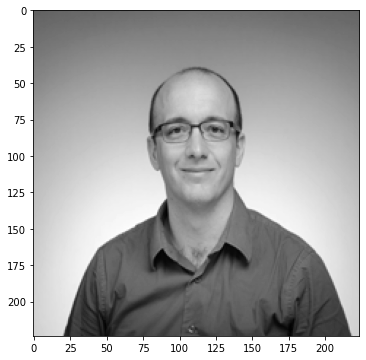

In [6]:
# Load and display image
img = Image.open('C:/Users/stefa/Downloads/image.jpg')
img = ImageOps.grayscale(img)
img = img.resize(size = (224, 224))
plot_image(img = img)

In [7]:
# Define filter
outline = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

In [8]:
# Implement convolution for a small part of the image
subset = np.array(img)[0:0+3, 0:0+3]
print(subset)
print(np.multiply(subset, outline))
print(np.sum(np.multiply(subset, outline)))

[[96 96 96]
 [97 97 97]
 [98 97 97]]
[[-96 -96 -96]
 [-97 776 -97]
 [-98 -97 -97]]
2


In [9]:
img_outlined = convolve(img = np.array(img), kernel = outline)
img_outlined

array([[ 2.,  3.,  2., ..., -2.,  0.,  1.],
       [-4., -3., -3., ...,  1., -5., -3.],
       [-1.,  0.,  0., ...,  3., -3.,  1.],
       ...,
       [ 4.,  4.,  3., ..., -4., -1.,  3.],
       [ 0.,  0., -1., ..., -2.,  0.,  3.],
       [-1.,  0., -2., ..., -5.,  0.,  4.]])

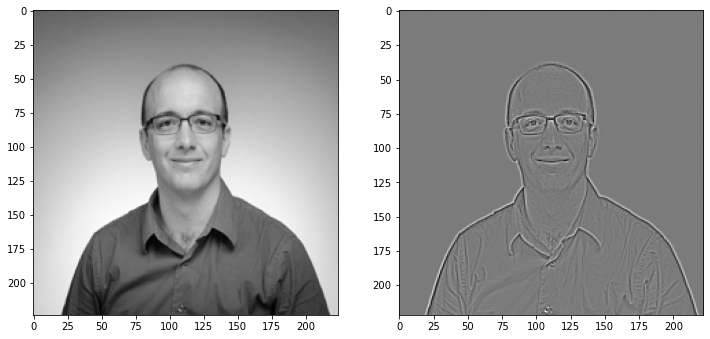

In [10]:
plot_two_images(
    img1 = img,
    img2 = img_outlined
)